# Milestone 1 Data Analysis

## Comparison of Optimization Strategies for Logistic Regression

This notebook supports the Milestone report for the capstone project. It performs:

- basic exploratory data analysis on the Iris dataset
- data preprocessing and standardization
- training with BGD, SGD, and MBGD
- comparison of convergence, accuracy, and computational cost
- a small learning-rate sensitivity experiment


## 1. Imports


In [94]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, load_wine

# Make sure the project root is importable when this notebook is run from /notebooks
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data_loader import load_data
from train import train_model
from evaluation import compare_runs
from plots import plot_loss_curves, plot_accuracy_curves

plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load the Iris dataset for EDA


In [95]:
iris = load_wine(as_frame=True)
df = iris.frame.copy()
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))

df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 3. Basic dataset inspection


In [96]:
print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['target_name'].value_counts())


Shape: (178, 15)

Column names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target', 'target_name']

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Class distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


## 4. Summary statistics


In [97]:
df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## 5. Pairwise visualization


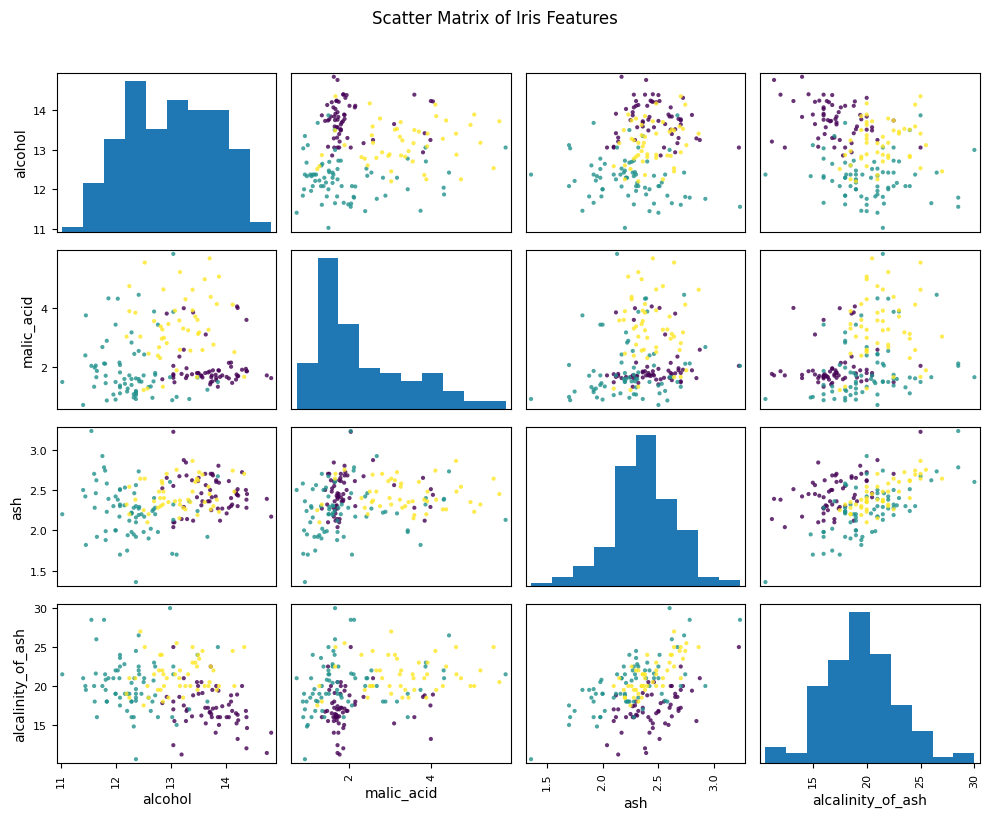

In [98]:
pd.plotting.scatter_matrix(
    df.iloc[:, :4],
    c=df['target'],
    figsize=(10, 8),
    diagonal='hist',
    alpha=0.8,
)
plt.suptitle('Scatter Matrix of Iris Features', y=1.02)
plt.tight_layout()
plt.show()


## 6. Correlation analysis


In [99]:
corr = df.iloc[:, :4].corr()
corr


,alcohol,malic_acid,ash,alcalinity_of_ash
alcohol,1.000000,0.094397,0.211545,-0.310235
malic_acid,0.094397,1.000000,0.164045,0.288500
ash,0.211545,0.164045,1.000000,0.443367
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000


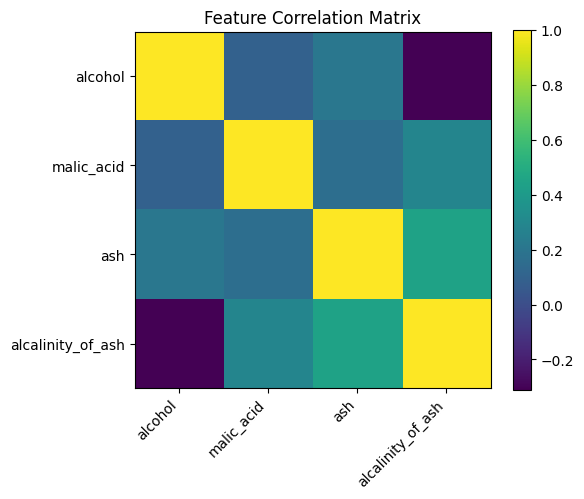

In [100]:
plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 7. Load standardized train/test data


In [101]:
X_train, X_test, y_train, y_test = load_data(test_size=0.2, random_state=42)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Training class counts:', np.bincount(y_train))
print('Test class counts:', np.bincount(y_test))


Training shape: (120, 4)
Test shape: (30, 4)
Training class counts: [40 40 40]
Test class counts: [10 10 10]


## 8. Main experiment: BGD vs SGD vs MBGD



Repeated-trials summary (mean ± std over seeds):

  optimizer  mean_final_test_acc  std_final_test_acc  mean_final_test_loss  \
0       bgd             0.913333            0.090062              0.281341   
1      mbgd             0.960000            0.054772              0.141034   
2       sgd             0.973333            0.036515              0.078373   

   std_final_test_loss  mean_epoch_time  
0             0.067905         0.000096  
1             0.049767         0.000201  
2             0.038725         0.001670  


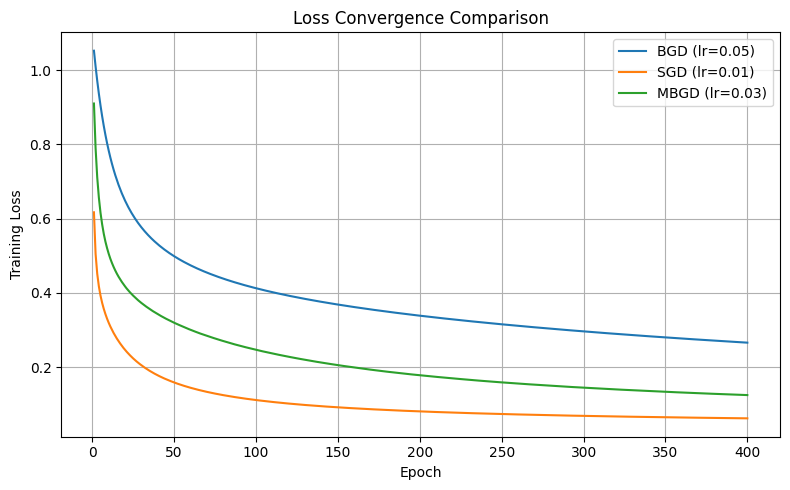

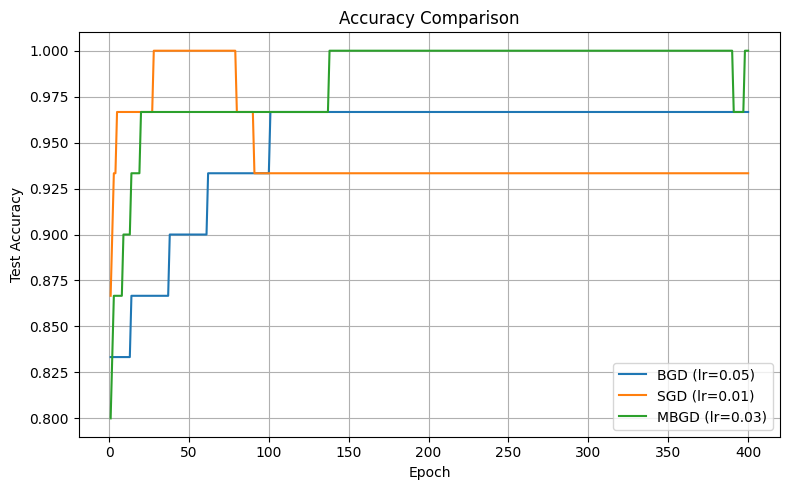

In [102]:
seeds = [0, 1, 2, 3, 4]  # repeat trials with these random seeds

settings = [
    {"optimizer": "bgd", "learning_rate": 0.05, "epochs": 400, "batch_size": 16},
    {"optimizer": "sgd", "learning_rate": 0.01, "epochs": 400, "batch_size": 16},
    {"optimizer": "mbgd", "learning_rate": 0.03, "epochs": 400, "batch_size": 16},
]

results = []
last_histories = {}

for seed in seeds:
    # ensure reproducible split / RNG for each trial
    np.random.seed(seed)
    
    X_train, X_test, y_train, y_test = load_data(test_size=0.2, random_state=seed)

    for cfg in settings:
        _, history = train_model(
            X_train,
            y_train,
            X_test,
            y_test,
            optimizer=cfg["optimizer"],
            learning_rate=cfg["learning_rate"],
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
        )

        results.append(
            {
                "seed": seed,
                "optimizer": cfg["optimizer"],
                "final_train_loss": history["train_loss"][-1],
                "final_test_loss": history["test_loss"][-1],
                "final_train_acc": history["train_acc"][-1],
                "final_test_acc": history["test_acc"][-1],
                "avg_epoch_time": float(np.mean(history.get("epoch_time", [0]))),
            }
        )

        # keep last history per optimizer for quick plotting
        last_histories[cfg["optimizer"]] = history

df = pd.DataFrame(results)
summary_df = (
    df.groupby("optimizer")
    .agg(
        mean_final_test_acc=("final_test_acc", "mean"),
        std_final_test_acc=("final_test_acc", "std"),
        mean_final_test_loss=("final_test_loss", "mean"),
        std_final_test_loss=("final_test_loss", "std"),
        mean_epoch_time=("avg_epoch_time", "mean"),
    )
    .reset_index()
)

print("\nRepeated-trials summary (mean ± std over seeds):\n")
print(summary_df)

# plot curves for the last seed run (one per optimizer)
histories = [last_histories[cfg["optimizer"]] for cfg in settings]
plot_loss_curves(histories)
plot_accuracy_curves(histories)

## 9. Plot convergence and accuracy curves


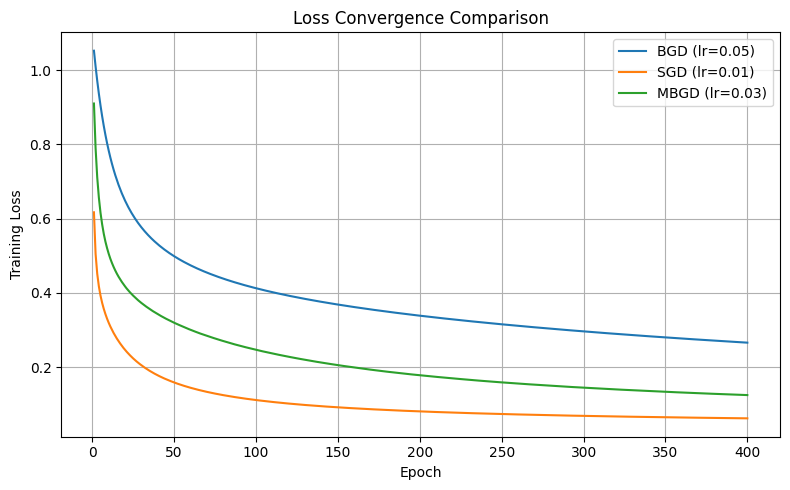

In [103]:
plot_loss_curves(histories)


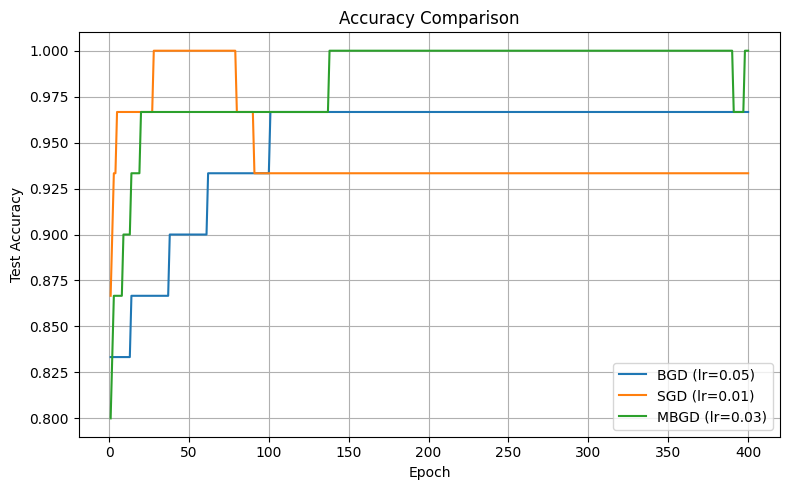

In [104]:
plot_accuracy_curves(histories)


## 9a. Normalized convergence analysis: Updates and wall-clock time

The epoch-based plots above treat each optimizer equally despite their different update frequencies. BGD makes 1 parameter update per epoch, while SGD makes n_samples updates per epoch, and MBGD makes ceil(n_samples / batch_size) updates. This section normalizes the convergence curves by plotting against cumulative parameter updates and cumulative wall-clock time to enable a more rigorous comparison.

In [105]:
def compute_updates_per_epoch(n_samples, optimizer, batch_size=16):
    """
    Compute the number of parameter updates for each optimizer per epoch.
    
    BGD: 1 update per epoch (full batch)
    SGD: n_samples updates per epoch (1 sample per batch)
    MBGD: ceil(n_samples / batch_size) updates per epoch
    """
    if optimizer == "bgd":
        return 1
    elif optimizer == "sgd":
        return n_samples
    elif optimizer == "mbgd":
        return int(np.ceil(n_samples / batch_size))
    else:
        raise ValueError(f"Unknown optimizer: {optimizer}")


def add_cumulative_metrics(history, n_samples, batch_size=16):
    """
    Add cumulative parameter updates and cumulative wall-clock time to history.
    """
    optimizer = history["optimizer"]
    updates_per_epoch = compute_updates_per_epoch(n_samples, optimizer, batch_size)
    
    cumulative_updates = []
    cumulative_time = []
    
    total_updates = 0
    total_time = 0.0
    
    for i in range(len(history["epoch"])):
        total_updates += updates_per_epoch
        total_time += history["epoch_time"][i]
        cumulative_updates.append(total_updates)
        cumulative_time.append(total_time)
    
    history["cumulative_updates"] = cumulative_updates
    history["cumulative_time"] = cumulative_time
    history["updates_per_epoch"] = updates_per_epoch


# Add cumulative metrics to the last run's histories
n_train_samples = X_train.shape[0]
batch_sizes = {"bgd": 16, "sgd": 1, "mbgd": 16}

for h in histories:
    add_cumulative_metrics(h, n_train_samples, batch_sizes.get(h["optimizer"], 16))

In [106]:
def plot_loss_by_updates(histories):
    """Plot training loss convergence vs cumulative parameter updates."""
    plt.figure(figsize=(8, 5))
    for h in histories:
        label = f"{h['optimizer'].upper()} (lr={h['learning_rate']}, {h['updates_per_epoch']} updates/epoch)"
        plt.plot(h["cumulative_updates"], h["train_loss"], marker='o', label=label, alpha=0.7)
    plt.xlabel("Cumulative Parameter Updates")
    plt.ylabel("Training Loss")
    plt.title("Loss Convergence vs Parameter Updates")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_loss_by_time(histories):
    """Plot training loss convergence vs cumulative wall-clock time."""
    plt.figure(figsize=(8, 5))
    for h in histories:
        label = f"{h['optimizer'].upper()} (lr={h['learning_rate']})"
        plt.plot(h["cumulative_time"], h["train_loss"], marker='o', label=label, alpha=0.7)
    plt.xlabel("Cumulative Wall-Clock Time (seconds)")
    plt.ylabel("Training Loss")
    plt.title("Loss Convergence vs Wall-Clock Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_accuracy_by_updates(histories):
    """Plot test accuracy convergence vs cumulative parameter updates."""
    plt.figure(figsize=(8, 5))
    for h in histories:
        label = f"{h['optimizer'].upper()} (lr={h['learning_rate']}, {h['updates_per_epoch']} updates/epoch)"
        plt.plot(h["cumulative_updates"], h["test_acc"], marker='o', label=label, alpha=0.7)
    plt.xlabel("Cumulative Parameter Updates")
    plt.ylabel("Test Accuracy")
    plt.title("Accuracy Convergence vs Parameter Updates")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_accuracy_by_time(histories):
    """Plot test accuracy convergence vs cumulative wall-clock time."""
    plt.figure(figsize=(8, 5))
    for h in histories:
        label = f"{h['optimizer'].upper()} (lr={h['learning_rate']})"
        plt.plot(h["cumulative_time"], h["test_acc"], marker='o', label=label, alpha=0.7)
    plt.xlabel("Cumulative Wall-Clock Time (seconds)")
    plt.ylabel("Test Accuracy")
    plt.title("Accuracy Convergence vs Wall-Clock Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Loss convergence: three perspectives

Below we compare the three convergence representations for the same final seed's training run.

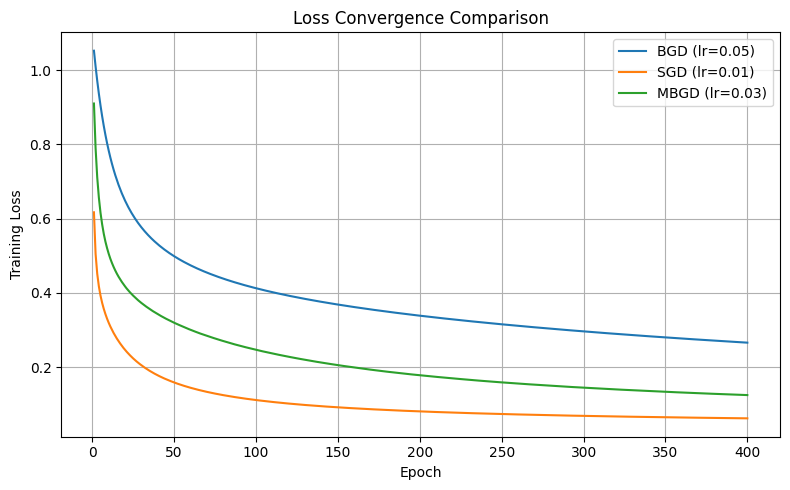

In [107]:
plot_loss_curves(histories)  # epoch-based (original)

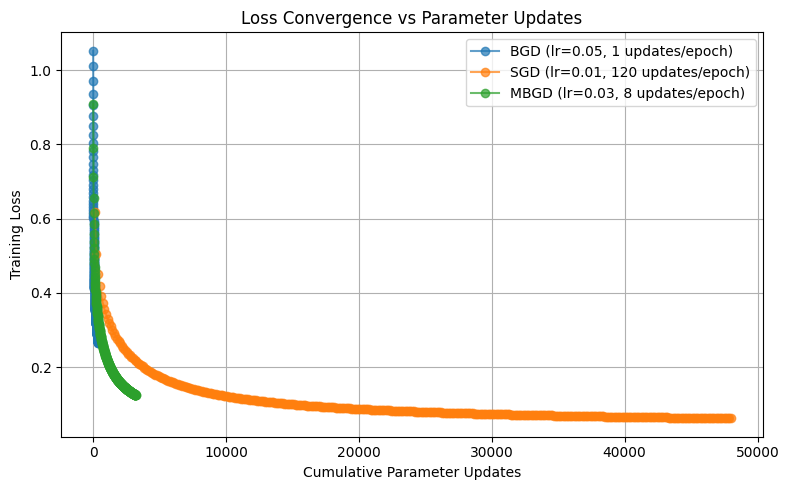

In [108]:
plot_loss_by_updates(histories)  # update-based (normalized by parameter updates)

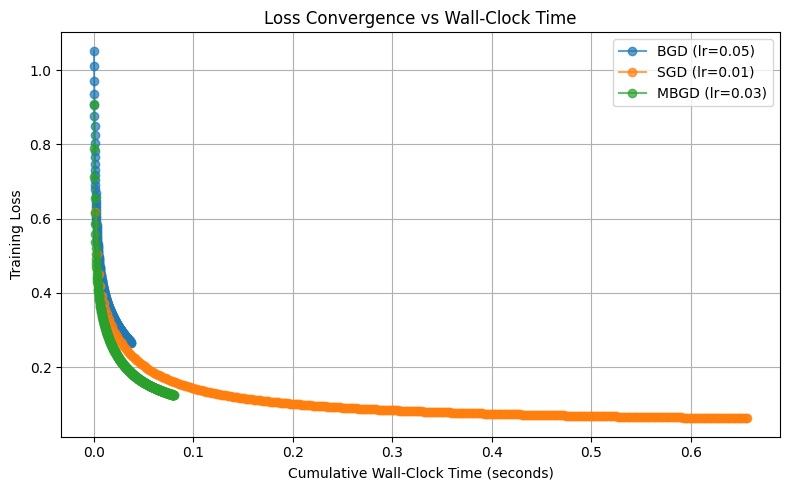

In [109]:
plot_loss_by_time(histories)  # time-based (normalized by wall-clock time)

### Accuracy convergence: three perspectives

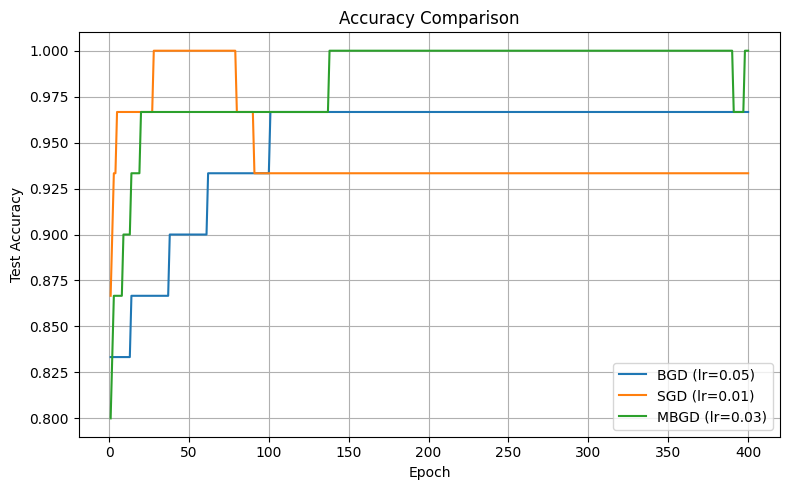

In [110]:
plot_accuracy_curves(histories)  # epoch-based (original)

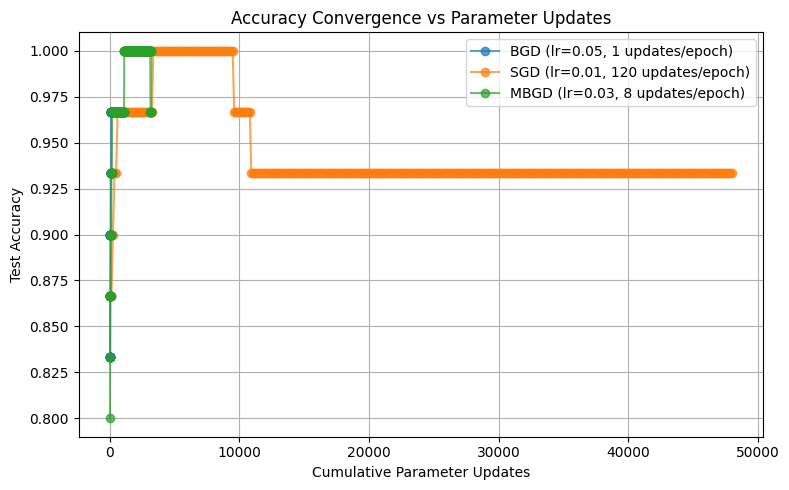

In [111]:
plot_accuracy_by_updates(histories)  # update-based (normalized by parameter updates)

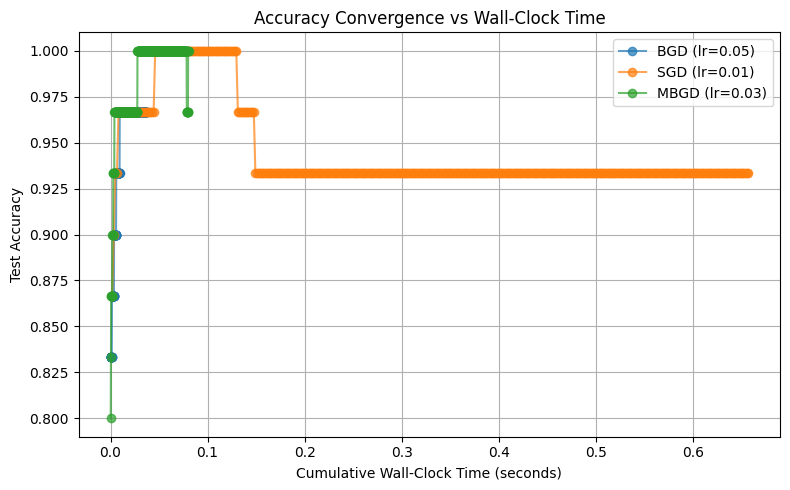

In [112]:
plot_accuracy_by_time(histories)  # time-based (normalized by wall-clock time)

### Interpretation: Normalized convergence analysis

The three representations above reveal important differences in how the optimizers compare when normalized for computational effort:

- **Epoch-based plot**: Shows convergence speed in wall-clock epochs. SGD appears fastest here because it makes many updates per epoch.
- **Update-based plot**: Normalizes by parameter updates. This reveals how efficiently each optimizer uses its available updates to reduce loss/improve accuracy.
- **Time-based plot**: Shows real computational cost in seconds. This accounts for both the number of updates and the per-update overhead, revealing practical efficiency on the hardware.

For stochastic optimizers (SGD, MBGD), the wall-clock time perspective is often most relevant because it directly reflects the training cost incurred. The update-based perspective shows whether a method converges quickly *per update* when computational overhead is abstracted away.

## 9b. Variability across repeated trials

The repeated trials (5 seeds) enable measurement of training stability for each optimizer. Below we examine how much variance each optimizer exhibits due to stochastic effects and random initialization.

In [113]:
print("\n" + "="*80)
print("REPEATED-TRIALS SUMMARY: Mean ± Std Dev across 5 random seeds")
print("="*80)
print(summary_df.to_string(index=False))
print("\nInterpretation:")
print("- BGD typically shows low variance (deterministic updates on full batch).")
print("- SGD and MBGD show higher variance due to stochastic batch sampling.")
print("- Standard deviation in test accuracy indicates training stability.")
print("- High std_final_test_loss or std_final_test_acc suggests sensitivity to initialization/randomness.")


REPEATED-TRIALS SUMMARY: Mean ± Std Dev across 5 random seeds
optimizer  mean_final_test_acc  std_final_test_acc  mean_final_test_loss  std_final_test_loss  mean_epoch_time
      bgd             0.913333            0.090062              0.281341             0.067905         0.000096
     mbgd             0.960000            0.054772              0.141034             0.049767         0.000201
      sgd             0.973333            0.036515              0.078373             0.038725         0.001670

Interpretation:
- BGD typically shows low variance (deterministic updates on full batch).
- SGD and MBGD show higher variance due to stochastic batch sampling.
- Standard deviation in test accuracy indicates training stability.
- High std_final_test_loss or std_final_test_acc suggests sensitivity to initialization/randomness.


/tmp/ipykernel_65396/2952159138.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([subset['final_test_acc'].values], labels=[optimizer.upper()])
/tmp/ipykernel_65396/2952159138.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([subset['final_test_acc'].values], labels=[optimizer.upper()])
/tmp/ipykernel_65396/2952159138.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([subset['final_test_acc'].values], labels=[optimizer.upper()])


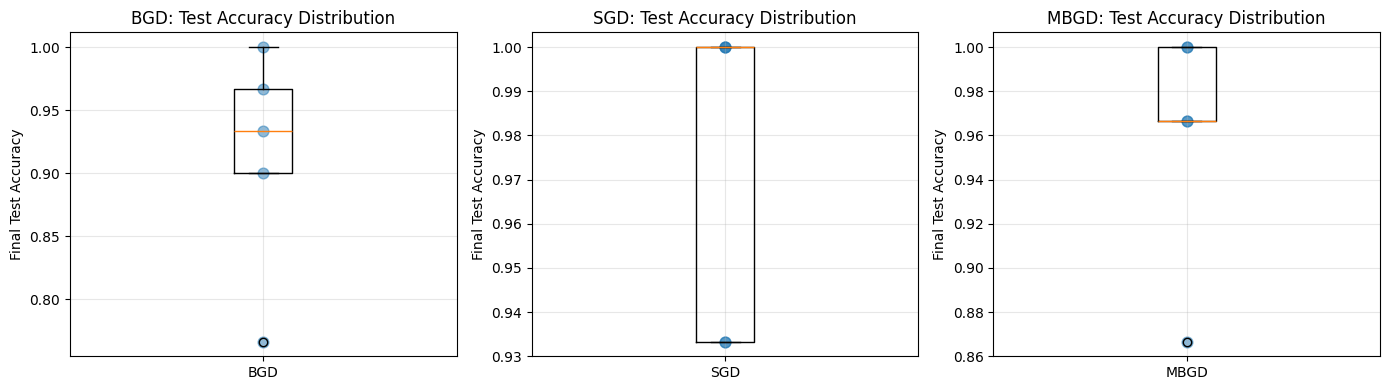


Test Accuracy Distribution by Optimizer:
           count    mean     std     min     25%     50%     75%  max
optimizer                                                            
bgd          5.0  0.9133  0.0901  0.7667  0.9000  0.9333  0.9667  1.0
mbgd         5.0  0.9600  0.0548  0.8667  0.9667  0.9667  1.0000  1.0
sgd          5.0  0.9733  0.0365  0.9333  0.9333  1.0000  1.0000  1.0


In [114]:
import matplotlib.pyplot as plt

# Visualize distribution of test accuracy across seeds for each optimizer
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, optimizer in enumerate(['bgd', 'sgd', 'mbgd']):
    ax = axes[idx]
    subset = df[df['optimizer'] == optimizer]
    ax.boxplot([subset['final_test_acc'].values], labels=[optimizer.upper()])
    ax.scatter([1] * len(subset), subset['final_test_acc'], alpha=0.5, s=60)
    ax.set_ylabel('Final Test Accuracy')
    ax.set_title(f'{optimizer.upper()}: Test Accuracy Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTest Accuracy Distribution by Optimizer:")
print(df.groupby('optimizer')['final_test_acc'].describe().round(4))

## 10. Learning-rate sensitivity experiment

This section runs a small hyperparameter sweep to show how each optimizer reacts to different learning rates. The sweep is updated to cover a wider range for all three optimizers. 


Best learning rate per optimizer based on final test accuracy:

optimizer  learning_rate  final_test_acc  final_train_acc
      bgd         0.2000        1.000000         0.950000
     mbgd         0.0300        1.000000         0.966667
      sgd         0.0005        0.966667         0.900000

Retrained models using the best learning rate for each optimizer.


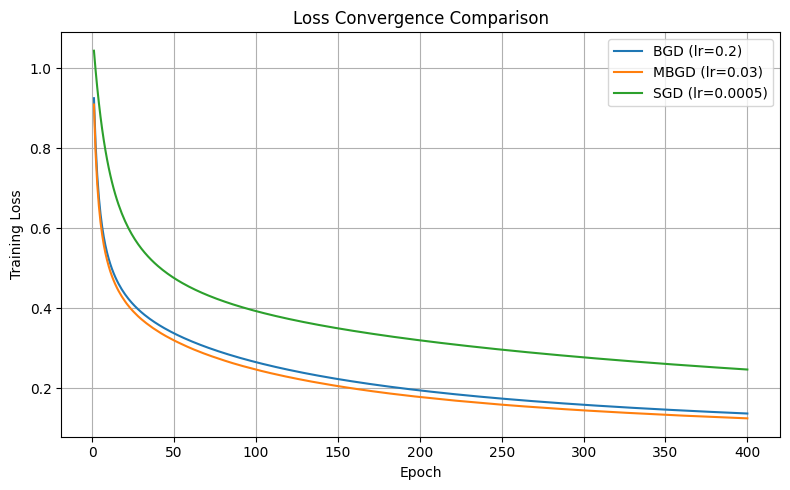

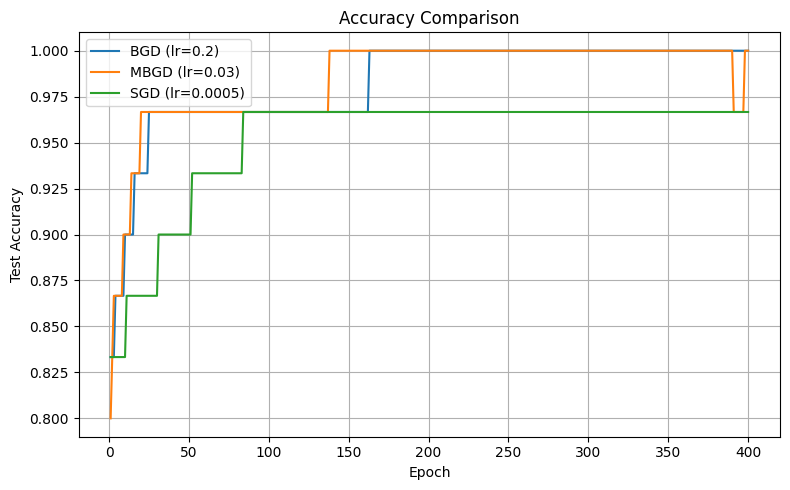

In [115]:
lr_grid = {
    'bgd': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    'sgd': [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    'mbgd': [0.001, 0.003, 0.01, 0.03, 0.05, 0.1, 0.2],
}

sweep_rows = []

for optimizer, lr_list in lr_grid.items():
    for lr in lr_list:
        _, history = train_model(
            X_train,
            y_train,
            X_test,
            y_test,
            optimizer=optimizer,
            learning_rate=lr,
            epochs=200,
            batch_size=16 if optimizer != 'sgd' else 1,
        )
        sweep_rows.append({
            'optimizer': optimizer,
            'learning_rate': lr,
            'final_train_loss': history['train_loss'][-1],
            'final_test_loss': history['test_loss'][-1],
            'final_train_acc': history['train_acc'][-1],
            'final_test_acc': history['test_acc'][-1],
            'avg_epoch_time': np.mean(history['epoch_time']),
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df = sweep_df.sort_values(['optimizer', 'learning_rate']).reset_index(drop=True)
sweep_df

best_idx = sweep_df.groupby('optimizer')['final_test_acc'].idxmax()
best_settings_df = sweep_df.loc[best_idx].sort_values('optimizer').reset_index(drop=True)

print('Best learning rate per optimizer based on final test accuracy:\n')
print(best_settings_df[['optimizer', 'learning_rate', 'final_test_acc', 'final_train_acc']].to_string(index=False))

best_histories = []
for _, row in best_settings_df.iterrows():
    optimizer = row['optimizer']
    learning_rate = row['learning_rate']
    batch_size = 1 if optimizer == 'sgd' else 16
    _, history = train_model(
        X_train,
        y_train,
        X_test,
        y_test,
        optimizer=optimizer,
        learning_rate=learning_rate,
        epochs=400,
        batch_size=batch_size,
    )
    best_histories.append(history)

print('\nRetrained models using the best learning rate for each optimizer.')
plot_loss_curves(best_histories)
plot_accuracy_curves(best_histories)

## 11. Visualize test accuracy across learning rates


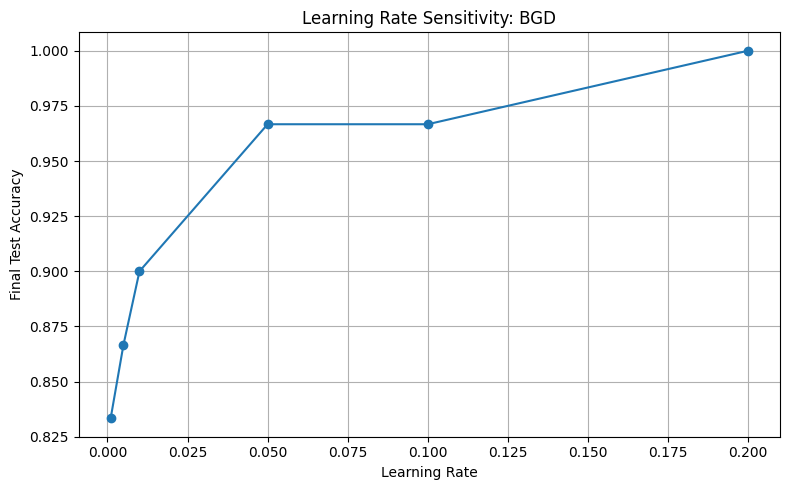

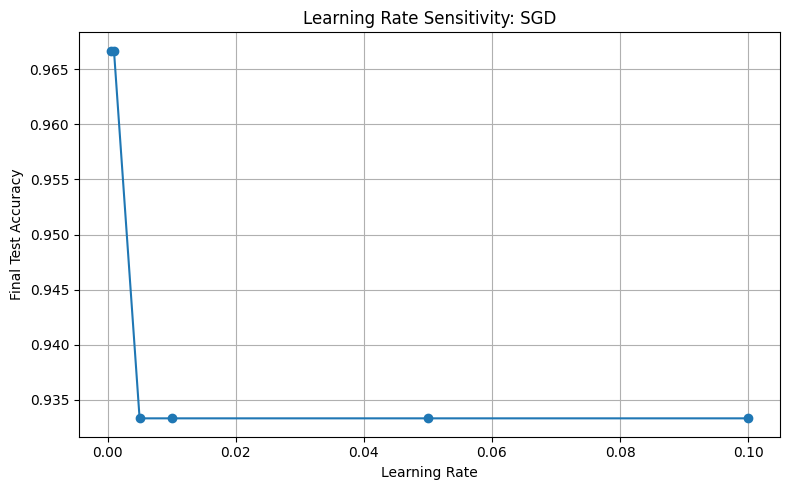

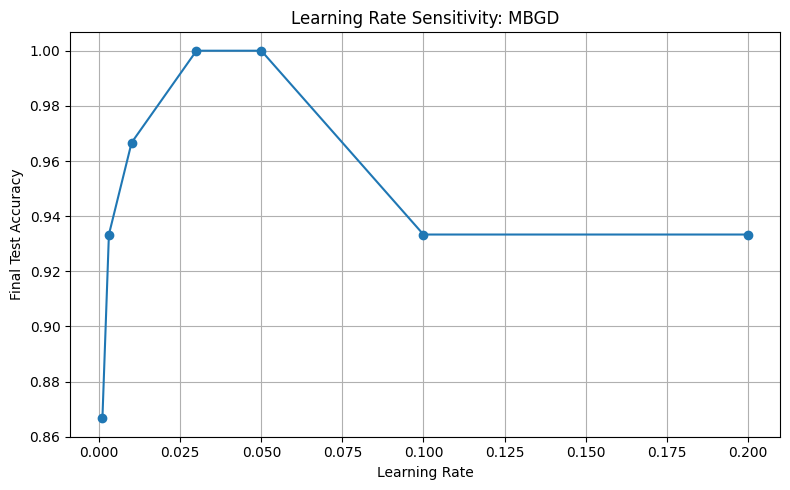

In [116]:
for optimizer in ['bgd', 'sgd', 'mbgd']:
    subset = sweep_df[sweep_df['optimizer'] == optimizer].sort_values('learning_rate')
    plt.figure()
    plt.plot(subset['learning_rate'], subset['final_test_acc'], marker='o')
    plt.xlabel('Learning Rate')
    plt.ylabel('Final Test Accuracy')
    plt.title(f'Learning Rate Sensitivity: {optimizer.upper()}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 12. Observations

- All three optimization methods converge on the Iris dataset.
- SGD often reaches lower loss faster in epoch-based comparison because it updates parameters more frequently.
- BGD tends to be smoother but slower.
- MBGD usually provides a compromise between computational efficiency and predictive performance.
- Learning rate strongly affects both convergence speed and final accuracy.
